In [ ]:
%pip install colour-science

In [2]:
# imports
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
import colour
import numpy as np

# Metric for finding distance between colors
def delta_e_distance(pixel1, pixel2):
    # Rescale pixel1 from OpenCV's 0-255 range to standard CIELAB ranges
    L1_true = pixel1[0] * 100 / 255
    a1_true = pixel1[1] - 128
    b1_true = pixel1[2] - 128
    scaled_pixel1 = np.array([L1_true, a1_true, b1_true])

    # Rescale pixel2 from OpenCV's 0-255 range to standard CIELAB ranges
    L2_true = pixel2[0] * 100 / 255
    a2_true = pixel2[1] - 128
    b2_true = pixel2[2] - 128
    scaled_pixel2 = np.array([L2_true, a2_true, b2_true])

    # Use colour.delta_e with method='CIE2000' for Delta E 2000 calculation
    return colour.delta_E(scaled_pixel1, scaled_pixel2, method='CIE2000')

## Import the Arktal Beads Dataset


In [4]:
df = pd.read_excel("Arktal Beads.xlsx", usecols="A:D")

df.head()

,Color Code,Red,Green,Blue
0,A1,250,245,205
1,A2,255,249,211
2,A3,255,235,140
3,A4,255,210,60
4,A5,249,202,52


## Convert Dataframe from RGB to CIELAB

In [5]:
# Extract values
rgb_values = df[['Red', 'Green', 'Blue']].values

# Reshape to match opencv format
rgb_values = rgb_values.reshape(-1, 1, 3).astype(np.uint8)

# Convert to LAB
lab_values = cv2.cvtColor(rgb_values, cv2.COLOR_RGB2LAB)

# Add LAB values to dataframe
df['L'] = lab_values[:, 0, 0]
df['A'] = lab_values[:, 0, 1]
df['B'] = lab_values[:, 0, 2]

df.head()

,Color Code,Red,Green,Blue,L,A,B
0,A1,250,245,205,245,123,148
1,A2,255,249,211,249,124,147
2,A3,255,235,140,237,122,176
3,A4,255,210,60,219,130,203
4,A5,249,202,52,212,131,203


In [6]:
# X and y split
X = df[['L', 'A', 'B']]
y = df['Color Code']

# Create the Nearest Neighbors model

In [7]:
# Initialize the model with the custom delta_e_distance metric using colour-science
model = KNeighborsClassifier(n_neighbors=1, metric=delta_e_distance)
model.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",<function del...001E7140976A0>
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
larger_model = KNeighborsClassifier(n_neighbors=5, metric=delta_e_distance)
larger_model.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",<function del...001E7140976A0>
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Bring in the new Image and Clean it

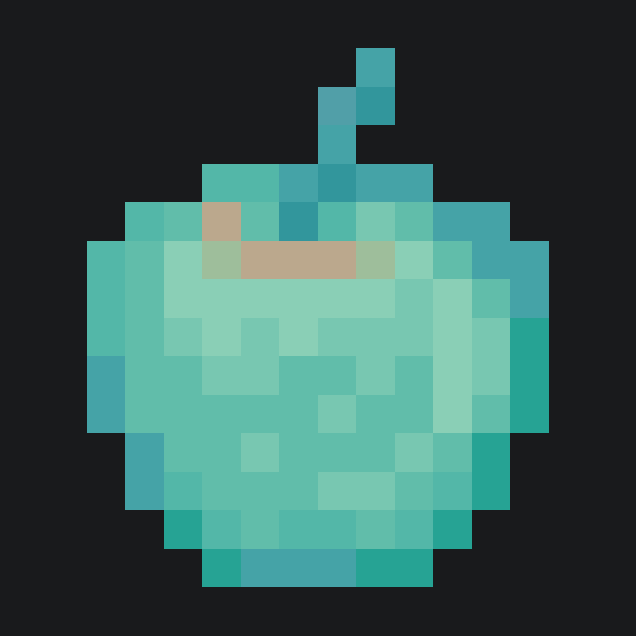

In [9]:
# Read in the Image
img = cv2.imread("ItemSprite_apple.png", cv2.IMREAD_UNCHANGED)
alpha = img[:, :, 3]
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Add back in the alpha value
img = cv2.merge((img, alpha))

# Show the image - use matplotlib for colab
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(img)

In [ ]:
img = cv2.resize(img,(16,16), cv2.INTER_LINEAR)

In [10]:
# Initialize the unique row with the first row
unique_pixels = np.unique(img[0], axis=0)

# Loop through and find unique pixels per row
for i in range(1, img.shape[0]):
  new_pixels = np.unique(img[i], axis=0)
  unique_pixels = np.concatenate([unique_pixels, new_pixels])

# Pull out all unique pixels
unique_pixels = np.unique(unique_pixels, axis=0)

# Remove any pixels with transparency of 0
unique_pixels = unique_pixels[unique_pixels[:, -1] != 0]
print(unique_pixels)

[[ 38 163 148 255]
 [ 50 150 156 255]
 [ 69 163 167 255]
 [ 81 159 168 255]
 [ 83 183 168 255]
 [ 97 189 170 255]
 [120 199 177 255]
 [138 207 182 255]
 [158 190 155 255]
 [187 168 141 255]]


### Ensure Unique Bead Assignment for Unique Image Pixels

To ensure that each unique pixel color extracted from the image is mapped to a unique bead color from the dataset, we need to move beyond simply finding the single closest neighbor independently for each pixel. The previous approach could lead to the same bead being recommended for multiple distinct image pixel colors.

We will implement a **greedy assignment strategy**:
1.  Calculate the Delta E distance between every unique pixel color from the image and every bead color in our dataset.
2.  Create a list of all possible (distance, unique_image_pixel_index, bead_dataset_index) tuples.
3.  Sort this list by distance in ascending order.
4.  Iterate through the sorted list, making assignments. For each (distance, unique_image_pixel_index, bead_dataset_index) tuple:
    *   If both the unique image pixel and the bead are currently unassigned, make the assignment.
    *   Mark both as assigned and store the mapping.

This method prioritizes the absolute closest matches globally, ensuring that once a bead is assigned, it cannot be assigned again to another unique image pixel.

In [11]:
# 1. Extract unique image pixel LAB values (excluding alpha channel)
lab_pixels_from_image = unique_pixels[:, :-1]

# 2. Extract bead LAB values and their color codes from the DataFrame
bead_lab_values = X.values # X contains L, A, B for beads
bead_color_codes = y.values # y contains 'Color Code'

# 3. Calculate all pairwise Delta E distances
# This will be a matrix of shape (num_unique_image_pixels, num_beads)
all_distances = np.zeros((len(lab_pixels_from_image), len(bead_lab_values)))

for i, img_pixel_lab in enumerate(lab_pixels_from_image):
    for j, bead_pixel_lab in enumerate(bead_lab_values):
        all_distances[i, j] = delta_e_distance(img_pixel_lab, bead_pixel_lab)

# 4. Create a list of (distance, image_pixel_idx, bead_idx) tuples
distance_tuples = []
for i in range(len(lab_pixels_from_image)): # Iterate over unique image pixels
    for j in range(len(bead_lab_values)):     # Iterate over all bead colors
        distance_tuples.append((all_distances[i, j], i, j))

# 5. Sort the tuples by distance (closest matches first)
distance_tuples.sort(key=lambda x: x[0])

# 6. Perform greedy assignment
assigned_image_pixels_indices = set()
assigned_beads_indices = set()
# Store mapping from unique image pixel LAB tuple to assigned bead color code
unique_pixel_to_bead_map = {}

for dist, img_idx, bead_idx in distance_tuples:
    # If both the image pixel and the bead are unassigned, make the assignment
    if img_idx not in assigned_image_pixels_indices and bead_idx not in assigned_beads_indices:
        current_img_pixel_lab_tuple = tuple(lab_pixels_from_image[img_idx])
        unique_pixel_to_bead_map[current_img_pixel_lab_tuple] = bead_color_codes[bead_idx]

        assigned_image_pixels_indices.add(img_idx)
        assigned_beads_indices.add(bead_idx)

    # Stop if all unique image pixels have been assigned a unique bead.
    # This assumes len(lab_pixels_from_image) <= len(bead_lab_values), which is true here (16 <= 394).
    if len(assigned_image_pixels_indices) == len(lab_pixels_from_image):
        break

print("--- Unique Pixel to Bead Assignments ---")
for lab_tuple, color_code in unique_pixel_to_bead_map.items():
    print(f"Image Pixel LAB {lab_tuple} -> Assigned Bead: {color_code}")

print(f"\nTotal unique image pixels assigned: {len(unique_pixel_to_bead_map)}")


--- Unique Pixel to Bead Assignments ---
Image Pixel LAB (81, 159, 168) -> Assigned Bead: G13
Image Pixel LAB (50, 150, 156) -> Assigned Bead: A12
Image Pixel LAB (158, 190, 155) -> Assigned Bead: F8
Image Pixel LAB (69, 163, 167) -> Assigned Bead: A9
Image Pixel LAB (120, 199, 177) -> Assigned Bead: F4
Image Pixel LAB (187, 168, 141) -> Assigned Bead: _C77
Image Pixel LAB (38, 163, 148) -> Assigned Bead: M14
Image Pixel LAB (97, 189, 170) -> Assigned Bead: F2
Image Pixel LAB (83, 183, 168) -> Assigned Bead: F13
Image Pixel LAB (138, 207, 182) -> Assigned Bead: _C05

Total unique image pixels assigned: 10


In [ ]:
# Grab distances and indices of k-nearest neighbors
distances, indices = larger_model.kneighbors(unique_pixels[:, :-1])

# Initialize # results wanted
top_n = 5

for i, pixel_lab in enumerate(unique_pixels[:, :-1]):
  # Reshape to 3 channels and convert to rgb
  reshaped_lab = pixel_lab.reshape(1, 1, 3)
  pixel_rgb = cv2.cvtColor(reshaped_lab, cv2.COLOR_LAB2RGB)
  pixel_rgb_print = pixel_rgb.reshape(3)

  print(f"\nPixel (RGB): {pixel_rgb_print}")

  # Convert rgb to bgr for im_show()
  pixel_bgr = cv2.cvtColor(pixel_rgb, cv2.COLOR_RGB2BGR)

  # Rescale rgb pixel to show color
  scaled_bgr_pixel = np.full((50, 50, 3), pixel_bgr, dtype=np.uint8)

  # Show the color
  cv2.imshow(scaled_bgr_pixel)

  # Grab top values
  top_indices = indices[i][:top_n]
  top_distances = distances[i][:top_n]

  # # For the top value, print out the color
  # top_pixel_bgr = df[['Blue', 'Green', 'Red']].iloc[top_indices[0]].values.reshape(1, 1, 3)

  # # Rescale bgr top pixel
  # scaled_top_pixel = np.full((50, 50, 3), top_pixel_bgr, dtype=np.uint8)

  # # Show the pixel
  # cv2.imshow(scaled_top_pixel)

  for j in range(top_n):
    # Grab color code
    predicted_color_code = y.iloc[top_indices[j]]

    # For the top value, print out the color
    top_pixel_bgr = df[['Blue', 'Green', 'Red']].iloc[top_indices[j]].values.reshape(1, 1, 3)

    # Rescale bgr top pixel
    scaled_top_pixel = np.full((50, 50, 3), top_pixel_bgr, dtype=np.uint8)

    # Show the pixel
    cv2.imshow(scaled_top_pixel)

  for j in range(top_n):
    # Grab color code
    predicted_color_code = y.iloc[top_indices[j]]
    print(f"Color code: {predicted_color_code}, Distance: {top_distances[j]:.2f}")

### Visualize the Image with Predicted Bead Labels

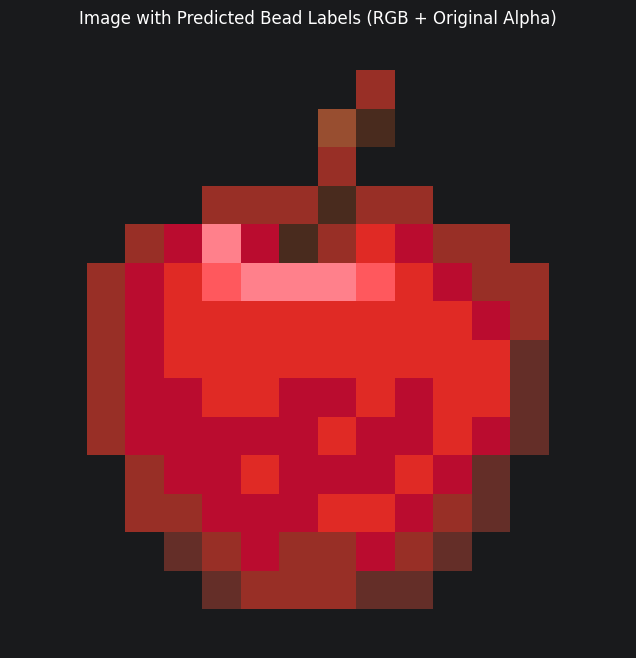


Predicted Color Codes for each pixel:
['Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent'
 'Transparent']
['Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'F6' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent']
['Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'F10' 'G8' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent']
['Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'F6' 'Transparent' 'Transparent'
 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent']
['Transparent' 'Transparent' 'Transparent' 'Transparent' 'Transparent' 'F6'
 'F6' '

In [19]:
color_code_to_rgb = df.set_index('Color Code')[['Red', 'Green', 'Blue']].apply(lambda x: x.tolist(), axis=1).to_dict()

height, width, _ = img.shape
predicted_img_rgba = np.zeros((height, width, 4), dtype=np.uint8)
predicted_color_codes_array = np.empty((height, width), dtype=object)

for r in range(height):
    for c in range(width):
        pixel_lab_alpha = img[r, c]
        pixel_lab = pixel_lab_alpha[:3]  # L, a, b values
        alpha_val = pixel_lab_alpha[3]    # Alpha value

        if alpha_val == 0:
            # Keep the pixel transparent if original alpha is 0
            predicted_img_rgba[r, c] = [0, 0, 0, 0]
            predicted_color_codes_array[r, c] = 'Transparent' # Assign a placeholder for transparent pixels
        else:
            # Predict the color code for non-transparent pixels
            predicted_color_code = model.predict(np.array([pixel_lab]))[0]
            predicted_color_codes_array[r, c] = predicted_color_code

            # Get RGB values for the predicted color code
            predicted_rgb = color_code_to_rgb[predicted_color_code]

            # Assign to the new image with original alpha
            predicted_img_rgba[r, c] = predicted_rgb + [alpha_val]

plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(predicted_img_rgba)
plt.title('Image with Predicted Bead Labels (RGB + Original Alpha)')
plt.show()

print("\nPredicted Color Codes for each pixel:")
for row in predicted_color_codes_array:
    print(row)

### Visualize Scaled Image with Text Labels

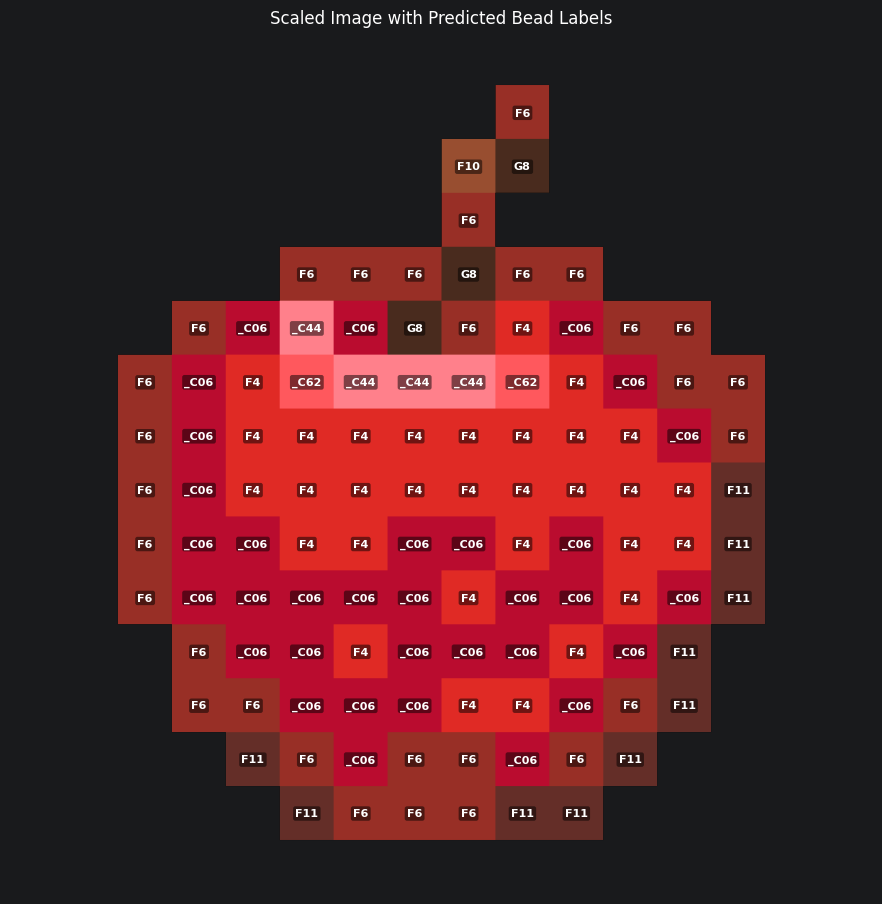

In [20]:
# Define block size for scaling and text visibility
block_size = 70 # Each original pixel will be represented by a 30x30 block

# Create a new blank image for the scaled visualization
scaled_height = height * block_size
scaled_width = width * block_size

# Initialize with a transparent background (RGBA)
labeled_image_rgba = np.zeros((scaled_height, scaled_width, 4), dtype=np.uint8)

# Prepare the figure for plotting
plt.figure(figsize=(scaled_width / 100, scaled_height / 100)) # Adjust figure size based on scaled image
plt.axis('off')

for r in range(height):
    for c in range(width):
        alpha_val = img[r, c, 3] # Get original alpha value
        color_code = predicted_color_codes_array[r, c]

        if alpha_val != 0 and color_code != 'Transparent':
            # Get RGB values for the predicted color code
            predicted_rgb = color_code_to_rgb[color_code]

            # Calculate the coordinates for the current block in the scaled image
            y_start, y_end = r * block_size, (r + 1) * block_size
            x_start, x_end = c * block_size, (c + 1) * block_size

            # Fill the block with the predicted color and full alpha
            labeled_image_rgba[y_start:y_end, x_start:x_end, :3] = predicted_rgb
            labeled_image_rgba[y_start:y_end, x_start:x_end, 3] = alpha_val # Use original alpha

            # Add text label
            plt.text(x_start + block_size / 2, y_start + block_size / 2,
                     color_code,
                     color='white', # Text color
                     ha='center', va='center', # Center text in the block
                     fontsize=8, # Adjust font size as needed
                     weight='bold', # Make text bold for better visibility
                     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')) # Background for text

# Display the final labeled image
plt.imshow(labeled_image_rgba)
plt.title('Scaled Image with Predicted Bead Labels')
plt.show()

In [ ]:
color_code_to_rgb = df.set_index('Color Code')[['Red', 'Green', 'Blue']].apply(lambda x: x.tolist(), axis=1).to_dict()

height, width, _ = img.shape
predicted_img_rgba = np.zeros((height, width, 4), dtype=np.uint8)
predicted_color_codes_array = np.empty((height, width), dtype=object)

# Define block size for scaling and text visibility
block_size = 70 # Each original pixel will be represented by a 30x30 block

# Create a new blank image for the scaled visualization
scaled_height = height * block_size
scaled_width = width * block_size

# Initialize with a transparent background (RGBA)
labeled_image_rgba = np.zeros((scaled_height, scaled_width, 4), dtype=np.uint8)

# Prepare the figure for plotting
plt.figure(figsize=(scaled_width / 100, scaled_height / 100)) # Adjust figure size based on scaled image
plt.axis('off')

for r in range(height):
    for c in range(width):
        alpha_val = img[r, c, 3] # Get original alpha value
        color_code = predicted_color_codes_array[r, c]

        if alpha_val != 0 and color_code != 'Transparent':
            # Get RGB values for the predicted color code
            predicted_rgb = color_code_to_rgb[color_code]

            # Calculate the coordinates for the current block in the scaled image
            y_start, y_end = r * block_size, (r + 1) * block_size
            x_start, x_end = c * block_size, (c + 1) * block_size

            # Fill the block with the predicted color and full alpha
            labeled_image_rgba[y_start:y_end, x_start:x_end, :3] = predicted_rgb
            labeled_image_rgba[y_start:y_end, x_start:x_end, 3] = alpha_val # Use original alpha

            # Add text label
            plt.text(x_start + block_size / 2, y_start + block_size / 2,
                     color_code,
                     color='white', # Text color
                     ha='center', va='center', # Center text in the block
                     fontsize=8, # Adjust font size as needed
                     weight='bold', # Make text bold for better visibility
                     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')) # Background for text

# Display the final labeled image
plt.imshow(labeled_image_rgba)
plt.title('Scaled Image with Predicted Bead Labels')
plt.show()

In [18]:
color_code_to_rgb = df.set_index('Color Code')[['Red', 'Green', 'Blue']].apply(lambda x: x.tolist(), axis=1).to_dict()

height, width, _ = img.shape
predicted_img_rgba = np.zeros((height, width, 4), dtype=np.uint8)
predicted_color_codes_array = np.empty((height, width), dtype=object)



for r in range(height):
    for c in range(width):
        pixel_lab_alpha = img[r, c]
        pixel_lab = pixel_lab_alpha[:3]  # L, a, b values
        alpha_val = pixel_lab_alpha[3]    # Alpha value

        if alpha_val == 0:
            # Keep the pixel transparent if original alpha is 0
            predicted_img_rgba[r, c] = [0, 0, 0, 0]
            predicted_color_codes_array[r, c] = 'Transparent' # Assign a placeholder for transparent pixels
        else:
            # Predict the color code for non-transparent pixels
            predicted_color_code = model.predict(np.array([pixel_lab]))[0]
            predicted_color_codes_array[r, c] = predicted_color_code

            # Get RGB values for the predicted color code
            predicted_rgb = color_code_to_rgb[predicted_color_code]

            # Assign to the new image with original alpha
            predicted_img_rgba[r, c] = predicted_rgb + [alpha_val]

# Convert to bgra for CV2
predicted_img_bgra = cv2.cvtColor(predicted_img_rgba, cv2.COLOR_RGBA2BGRA)

block_size = 70

scaled_image = cv2.resize(predicted_img_bgra, (width * block_size, height * block_size), interpolation=cv2.INTER_NEAREST)

for r in range(height):
    for c in range(width):
        if predicted_color_codes_array[r, c] != 'Transparent':

            # Add text label
            (text_w, text_h), baseline = cv2.getTextSize(
                predicted_color_codes_array[r,c],
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                1
            )

            x = c * block_size + (block_size - text_w) // 2
            y = r * block_size + (block_size - text_h) // 2

            cv2.putText(
                scaled_image,
                predicted_color_codes_array[r,c],
                (x, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (255, 255, 255),
                1,
                cv2.LINE_AA
            )




cv2.imshow('Predicted Beads', scaled_image)
cv2.waitKey(0)
cv2.destroyAllWindows()




F11
